In [1]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import uncertainties

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.6
g.settings.legend_fontsize = 30


#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir='/feynman/work/dap/lcs/lg268561/UNIONS/chains/'
roots = ['SP_1500_IA','SP_1500']


## Retrieve the chains

In [2]:
#CREATE PARAMNAME FILE
for root in roots:
    with open(root_dir + '{}/samples_{}_1.txt'.format(root,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-2]
        file.close()

    with open(root_dir + '{}/getdist_{}.paramnames'.format(root,root), "w") as file:
        for i in range(len(params)):
            file.write(params[i].split('--')[1] + '\n')
        file.close()
    print(params)

['cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8_input', 'intrinsic_alignment_parameters--a', 'COSMOLOGICAL_PARAMETERS--OMEGA_LAMBDA', 'COSMOLOGICAL_PARAMETERS--S_8', 'COSMOLOGICAL_PARAMETERS--AS']
['cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8_input', 'COSMOLOGICAL_PARAMETERS--OMEGA_LAMBDA', 'COSMOLOGICAL_PARAMETERS--S_8', 'COSMOLOGICAL_PARAMETERS--AS']


In [4]:
#READ CHAIN

chains=[]
Nchains = 8

for root in roots:
    for i in range(1,Nchains+1):
        chain = np.loadtxt(root_dir + '{}/samples_{}_{}.txt'.format(root,root,i))

        np.savetxt(root_dir + '{}/getdist_{}_{}.txt'.format(root,root,i),  
                np.column_stack((np.ones_like(chain[:, -1]) ,-(chain[:, -1]-chain[:, -2]), chain[:, 0:-3])))
    
    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                                   settings={'ignore_rows':0.3})

    chains.append(chain)

/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_1.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_2.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_3.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_4.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_5.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_6.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_7.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500_IA/getdist_SP_1500_IA_8.txt
Removed 0.3 as burn in
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500/getdist_SP_1500_1.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500/getdist_SP_1500_8.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500/getdist_SP_1500_7.txt
/feynman/work/dap/lcs/lg268561/UNIONS/chains/SP_1500/getdist_SP_1500_6.txt
/feynman/work/dap/lcs/lg26856

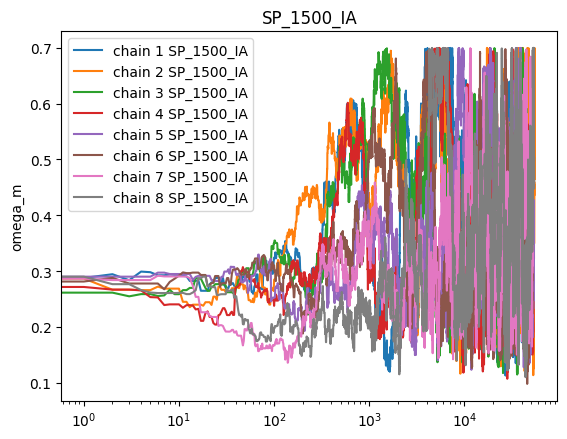

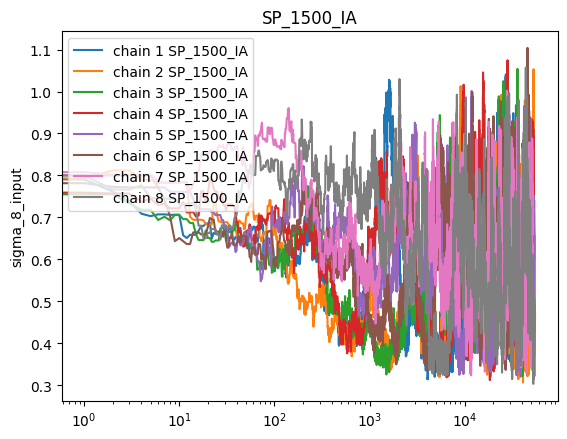

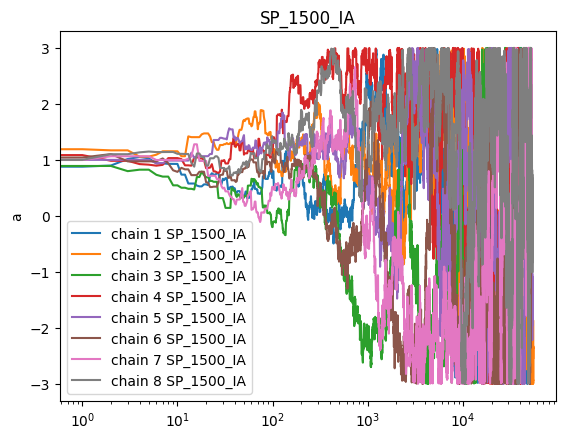

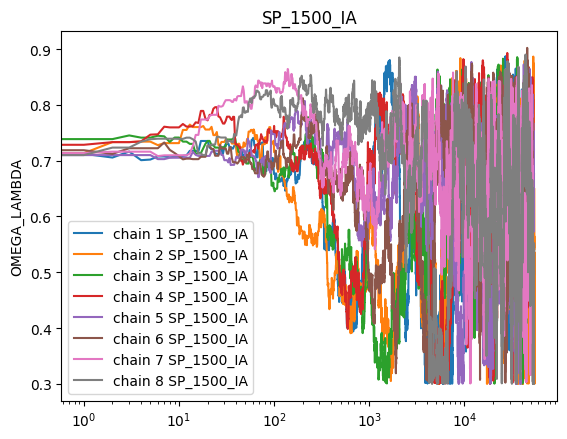

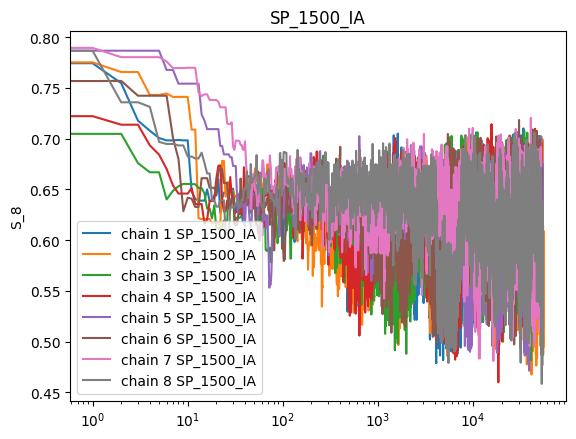

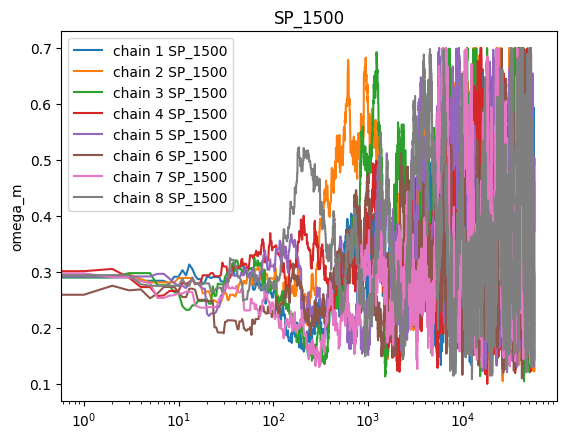

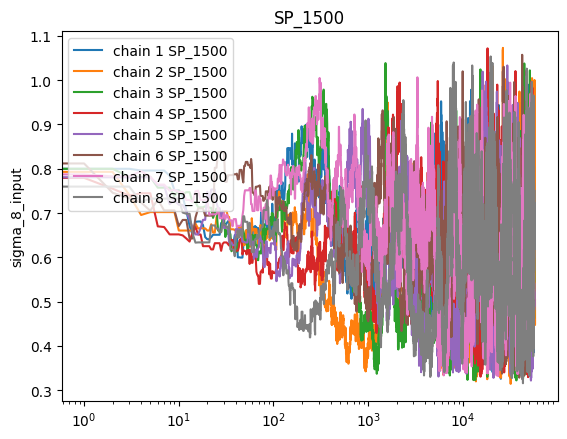

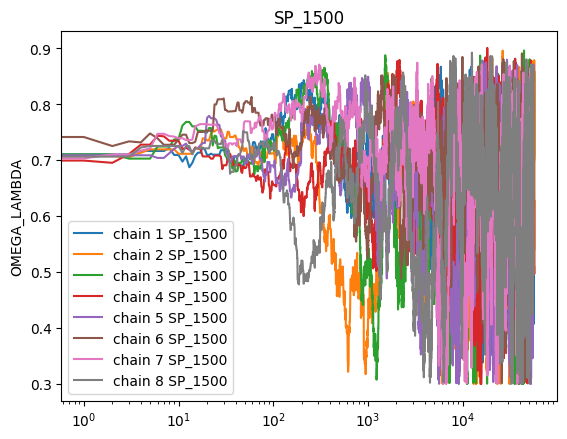

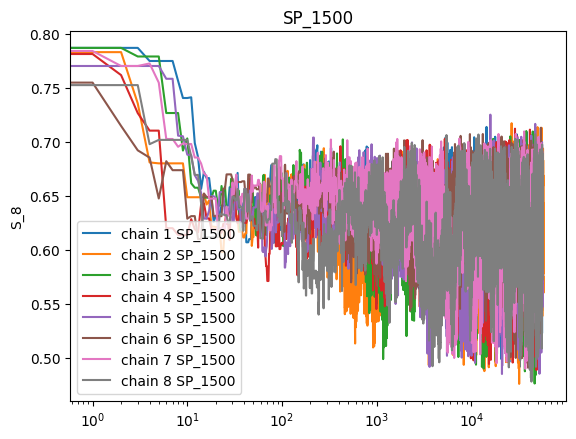

In [7]:
%matplotlib inline
for root in roots:
    params = np.genfromtxt(root_dir + '{}/getdist_{}.paramnames'.format(root,root),dtype='str')
    for idx,par in enumerate(params):
        for i in range(1,Nchains+1):
            trend = np.loadtxt(root_dir + '{}/getdist_{}_{}.txt'.format(root,root,i),usecols=idx+2)
            plt.plot(trend, label='chain {} {}'.format(i,root))
            plt.xscale('log')
            plt.legend()
            plt.ylabel('%s'%par)
            plt.title('%s'%root)
        plt.show()

## Plot the chain

R-1 = 0.21758876480468242
R-1 = None


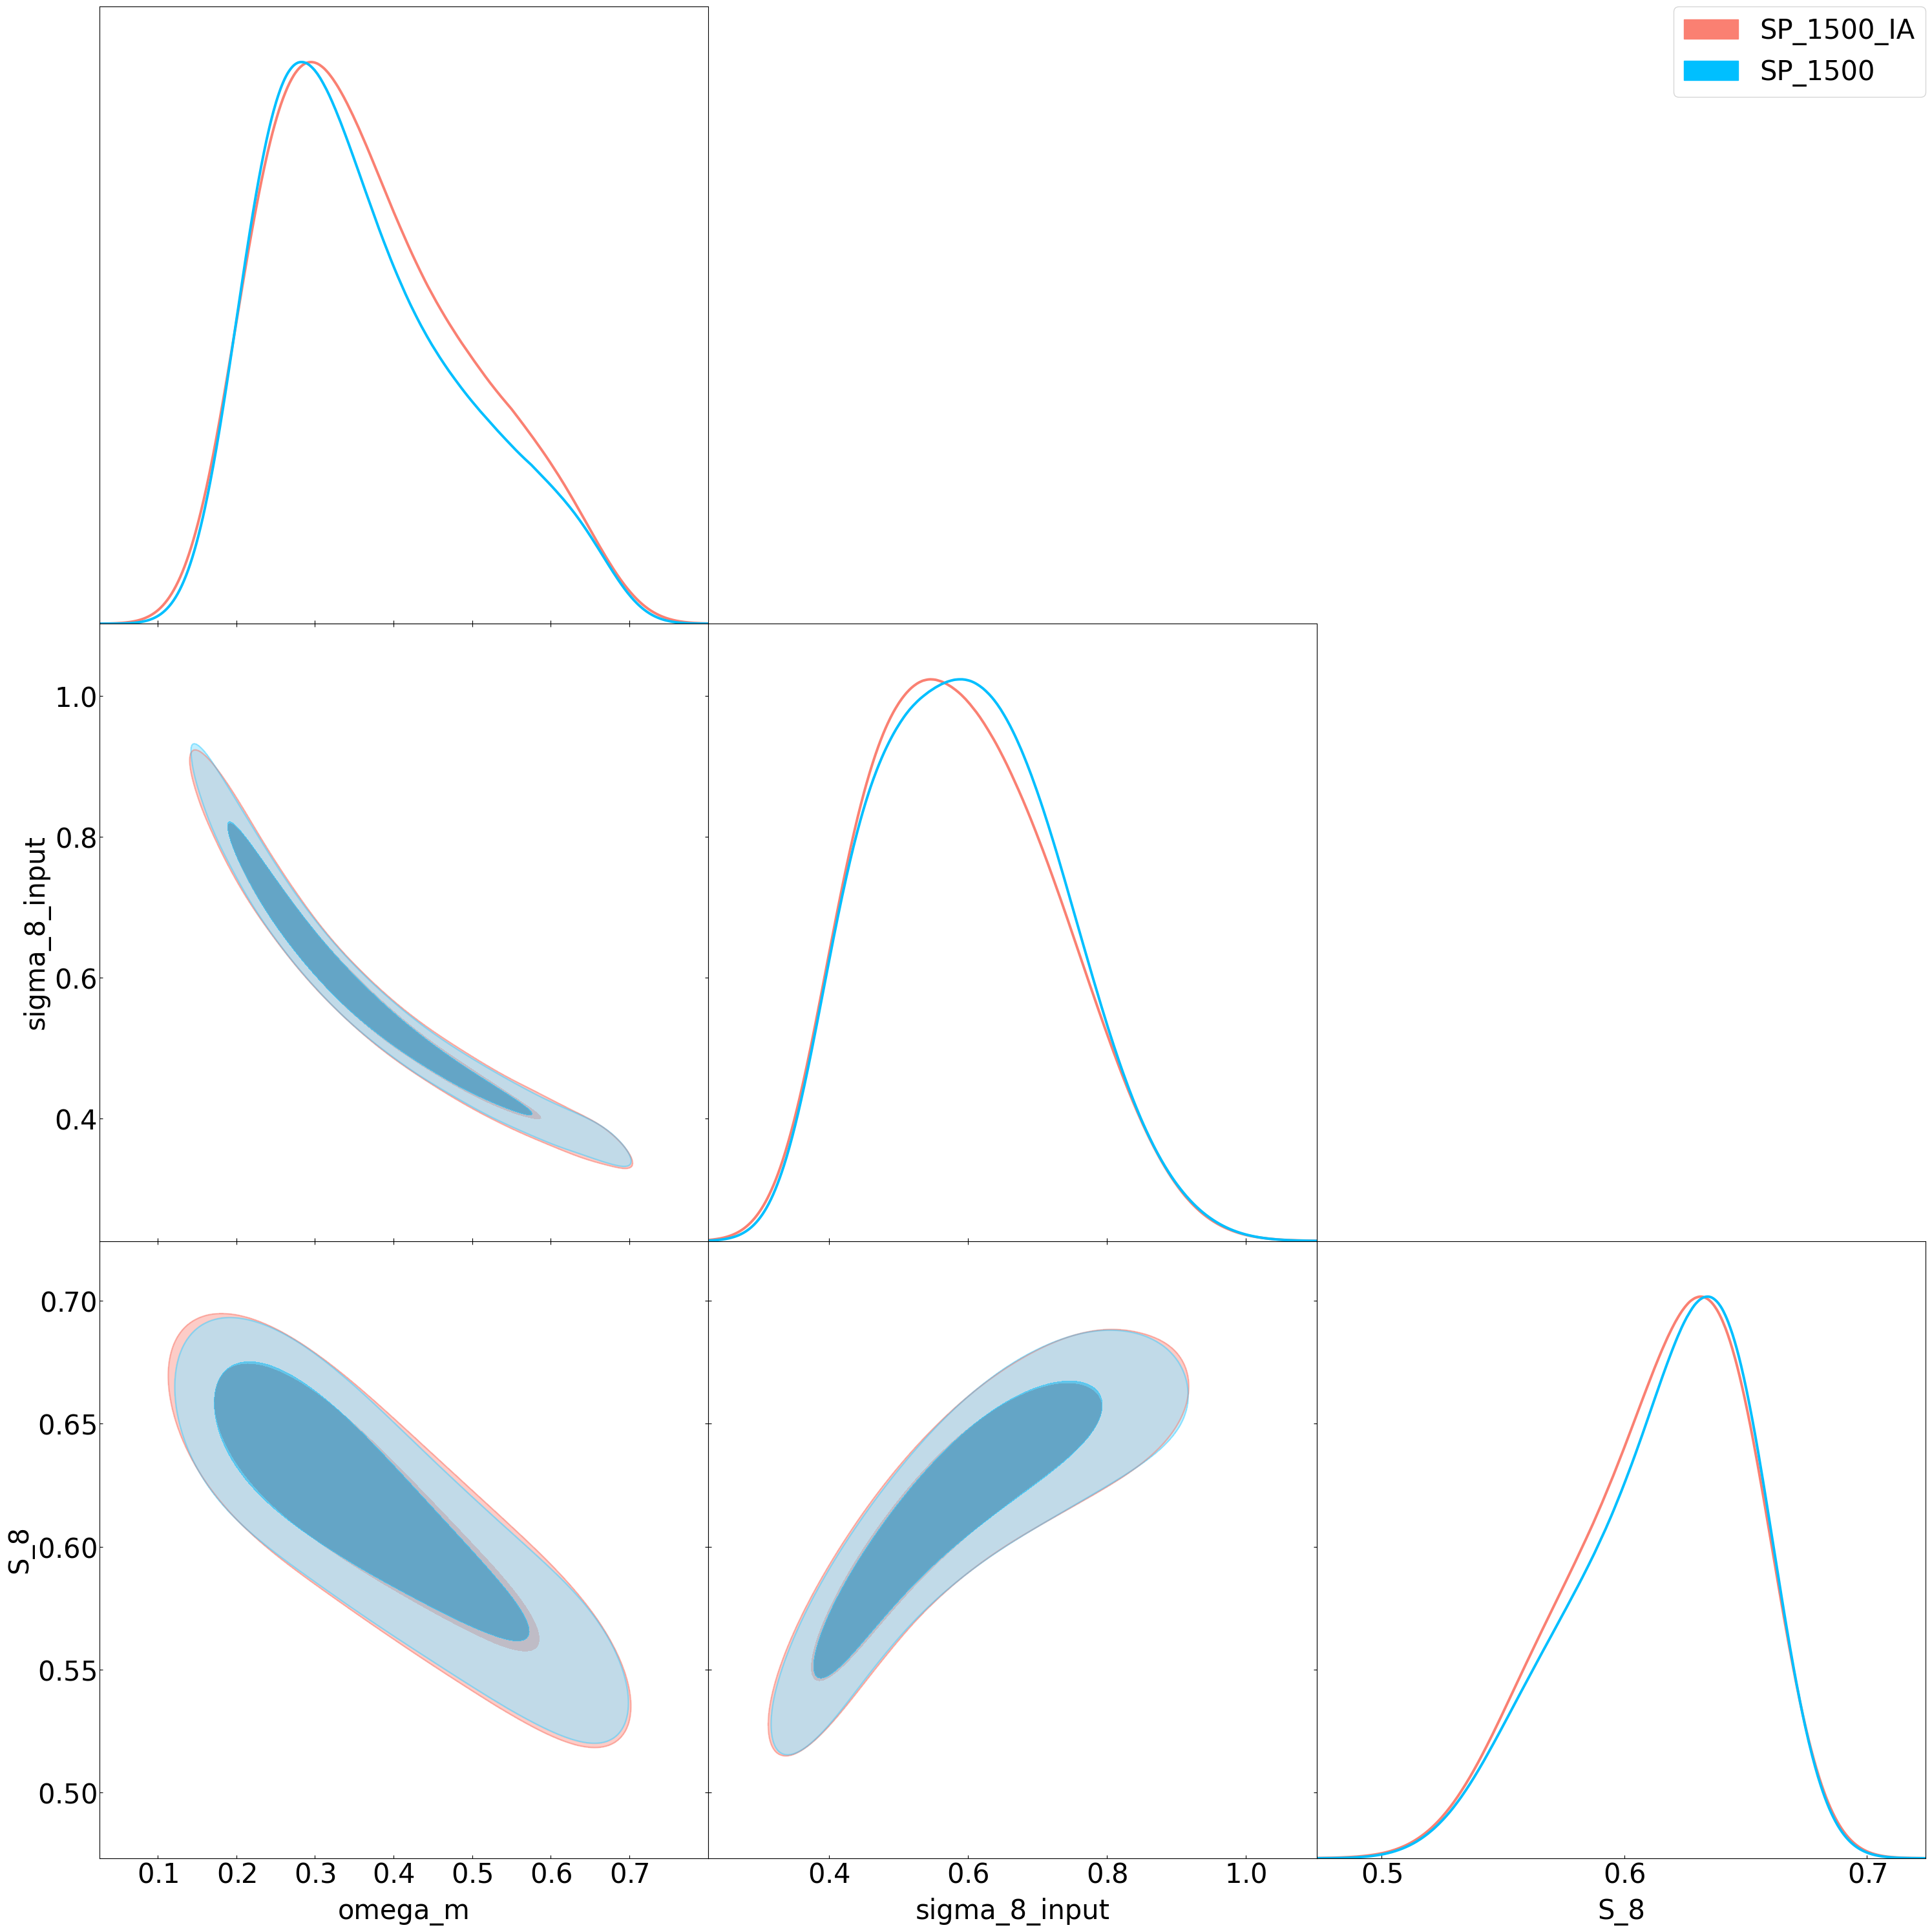

In [6]:
%matplotlib inline
for chain in chains:
    print('R-1 = %s' %chain.getGelmanRubin())

axs = g.set_axes(no_label_no_numbers=True)

g.triangle_plot(chains,['omega_m','sigma_8_input','S_8'],
                legend_labels=roots,
                # param_limits={'omega_m':[0.15,0.63],'SIGMA_8':[0.4,1],'S_8':[0.4,1],'ln10^10A_s':[1,4]},
                # param_limits={'omega_m':[0.15,0.3],'SIGMA_8':[0.8,0.95],'S_8':[0.65,0.8],'ln10^10A_s':[2.5,4]},
                # title_limit=1,
                # markers={'SIGMA_8':0.8,'omega_m':0.25,'OMEGA_LAMBDA':0.75,'S_8':0.7303},
                colors=['salmon','deepskyblue','green','salmon','deepskyblue','green'],
                # colors=['green','orange'],
                line_args=[{'color':'salmon'},{'color':'deepskyblue'},{'color':'green'},
                            {'color':'salmon','ls':'--'},{'color':'deepskyblue','ls':'--'},{'color':'green','ls':'--'}],
                filled=True)

# g.export('corner_plot_comparison.pdf')

### Output bestfit and sigma values

In [ ]:
#########BESTFIT AND SIGMA VALS##########
params = ['omega_m','ln10^10A_s','OMEGA_LAMBDA','SIGMA_8','S_8']
latex_params = [r'$\Omega_m$',r'$\ln(10^{10}A_s)$',r'$\Omega_\Lambda$',r'$\sigma_8$',
               r'$S_8$']
    
chain_options=chains

for chain in chain_options:

    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()

    for no in range(len(latex_params)):
        param_stats = margestats.parWithName(params[no])
        like_stats = likestats.parWithName(params[no])
        
        a = uncertainties.ufloat(param_stats.mean,((param_stats.mean-param_stats.limits[0].lower)+(param_stats.limits[0].upper-param_stats.mean))/2)
        latex_params[no] += '& $%.4g$ & '%(like_stats.bestfit_sample)
        latex_params[no] += '${:.3uL}$'.format(a)
        
for param in latex_params:
    param += r'\\'
    print(param)   
